# PostMortemID model notebook: E0 public-data baseline

**Initial public-data demonstration.** Every image in this notebook shows a live animal. Nothing here measures
post-mortem performance. The paired ante-mortem and post-mortem experiment (E1 to E7 in the proposal) is the next
research stage and needs data that have not been collected yet.

This notebook runs experiment E0 from the proposal: live-to-live 1:1 muzzle verification on public animals that the
models never saw during training or threshold setting. It covers the data, the cleaning, the baselines, the
proposed MobileNetV3-Large + ArcFace model, the initial metrics and an error analysis.

**To run from a clean checkout**

```bash
uv sync
uv run python ml/scripts/download_dataset.py
uv run jupyter lab ml/notebooks/01_e0_public_baseline.ipynb
```

Then *Restart kernel and run all*. On an Apple M-series laptop the full run takes about 20 minutes, most of it
the two fine-tuning runs. A CUDA GPU is used if present; CPU-only runs work but are slower.

## 1. Problem definition

**Input.** A photograph of a cattle muzzle. In the field study this will be a smartphone photo taken through the
capture app. In this notebook it is a pre-cropped muzzle image from a public database.

**Biometric.** The ridge and bead pattern on the hairless skin of the muzzle (the muzzle print).

**Verification (1:1).** Someone claims that a query image belongs to an enrolled animal. The system compares the
query with that animal's stored template and returns a similarity score. Two thresholds, both fixed on development
animals, turn the score into *Match* (score at or above the FAR 0.1% threshold), *No match* (below the FAR 1%
threshold) or *Review* (in between). This is a verification problem, not classification: the test animals are
never seen in training, so a closed list of classes would not help.

**What E0 can establish**

- that the data pipeline, identity-disjoint split, models and metrics work end to end;
- how well each model separates genuine and impostor pairs for unseen *live* animals whose images appear to come
  from one session;
- the model and thresholds used by the mobile prototype.

**What E0 cannot establish**

- whether muzzle identity survives death (RQ1), how the muzzle compares with the face (RQ2), the effect of
  changing phones (RQ3) or of time since slaughter (RQ4);
- performance on Rwandan cattle, smartphone images or abattoir conditions;
- suitability for insurance or any operational use.

In [1]:
import json
import platform

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from scipy.stats import spearmanr
from sklearn.metrics import roc_curve

from postmortemid import dataset, e0, lbp, metrics, paths, quality, splits, training
from postmortemid.imageops import load_rgb
from postmortemid.models import ArcFaceHead, MuzzleEmbedder
from postmortemid.prepare import prepare

cfg = json.loads((paths.CONFIGS / "e0.json").read_text())
device = training.pick_device()
training.seed_everything(cfg["train"]["seed"])
FIGURES = paths.REPO / "docs" / "figures"
FIGURES.mkdir(parents=True, exist_ok=True)
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})
print(f"Python {platform.python_version()}, PyTorch {torch.__version__}, device: {device}")

Python 3.12.13, PyTorch 2.14.1, device: mps


## 2. Dataset

| | |
|---|---|
| Source | Xiong, Li and Erickson (2022), *Beef Cattle Muzzle/Noseprint database for individual identification*, Zenodo, [doi:10.5281/zenodo.6324361](https://doi.org/10.5281/zenodo.6324361) |
| Paper | Li, Erickson and Xiong (2022), *Animals* 12(11), 1453 |
| Licence | [CC BY 4.0](https://creativecommons.org/licenses/by/4.0/). Raw images are not committed; `ml/scripts/download_dataset.py` fetches them and checks the archive hash. A few appear in this notebook's outputs for illustration, unmodified except for resizing. |
| Content | Muzzle crops of live feedlot cattle in the US Midwest, one folder per animal, photographed from outside the pens between 11 March and 31 July 2021 with a Fujifilm X-T4 and a 70-300 mm lens (Li et al., 2022). Only 272 crops keep EXIF data; those name a Fujifilm X-M1 (224) and a DJI Pocket (48). |

BC, Chaudhary and Nepal (2026) found 19 duplicate identities in this database and say their cleaned list and
split files are released with their code. The repository linked in their paper could not be found on
2 October 2026, so the cleaning in Section 3 is our own and is documented step by step.

In [2]:
prepared = prepare(cfg)
raw = prepared.raw
per_id = raw.groupby("identity").size()
short_side = np.minimum(raw["width"], raw["height"])
pd.Series(
    {
        "identities (folders)": raw["identity"].nunique(),
        "images": len(raw),
        "images per identity, min": per_id.min(),
        "images per identity, median": per_id.median(),
        "images per identity, max": per_id.max(),
        "short side px, median": short_side.median(),
        "short side px, 5th percentile": short_side.quantile(0.05),
        "images with a camera frame number": raw["frame"].notna().sum(),
    }
).to_frame("value")

,value
identities (folders),268.0
images,4923.0
"images per identity, min",4.0
"images per identity, median",16.0
"images per identity, max",70.0
"short side px, median",240.0
"short side px, 5th percentile",74.0
images with a camera frame number,4875.0


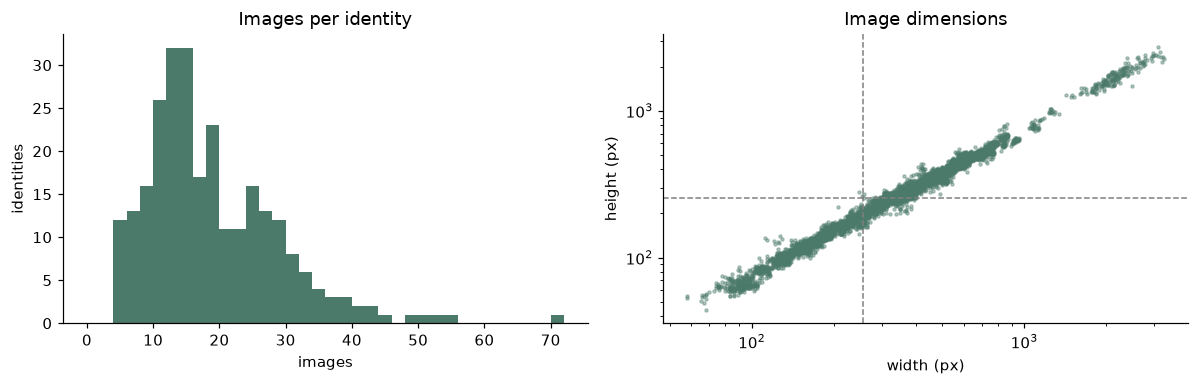

In [3]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
ax[0].hist(per_id, bins=range(0, per_id.max() + 3, 2), color="#4c7a6a")
ax[0].set(title="Images per identity", xlabel="images", ylabel="identities")
ax[1].scatter(raw["width"], raw["height"], s=4, alpha=0.4, color="#4c7a6a")
ax[1].set(
    title="Image dimensions", xlabel="width (px)", ylabel="height (px)", xscale="log", yscale="log"
)
ax[1].axhline(256, ls="--", c="grey", lw=1)
ax[1].axvline(256, ls="--", c="grey", lw=1)
plt.tight_layout()
plt.show()

The images are tight crops, so most are small: about half have a short side under 240 px. The dashed lines mark
256 px, the minimum the mobile app asks for (Section 4). Identity sizes range from 4 to 70 images.

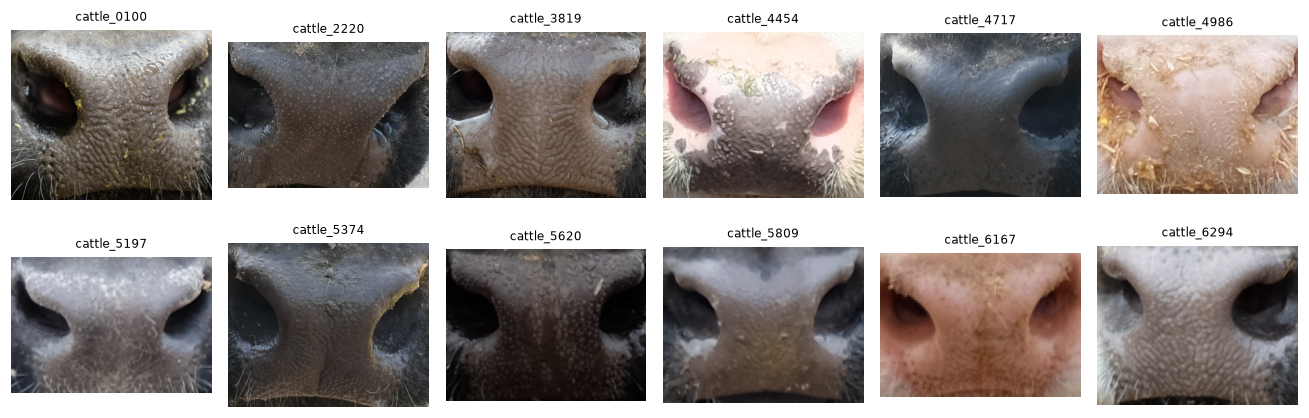

In [4]:
def show_grid(paths_, titles, cols=6, size=2.0):
    rows = int(np.ceil(len(paths_) / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(cols * size, rows * size * 1.05))
    for ax in np.ravel(axes):
        ax.axis("off")
    for ax, p, t in zip(np.ravel(axes), paths_, titles, strict=False):
        ax.imshow(load_rgb(paths.RAW / p))
        ax.set_title(t, fontsize=8)
    plt.tight_layout()
    plt.show()


sample_ids = sorted(raw["identity"].unique())[::22][:12]
first = raw[raw["identity"].isin(sample_ids)].groupby("identity").head(1)
show_grid(first["path"], first["identity"])

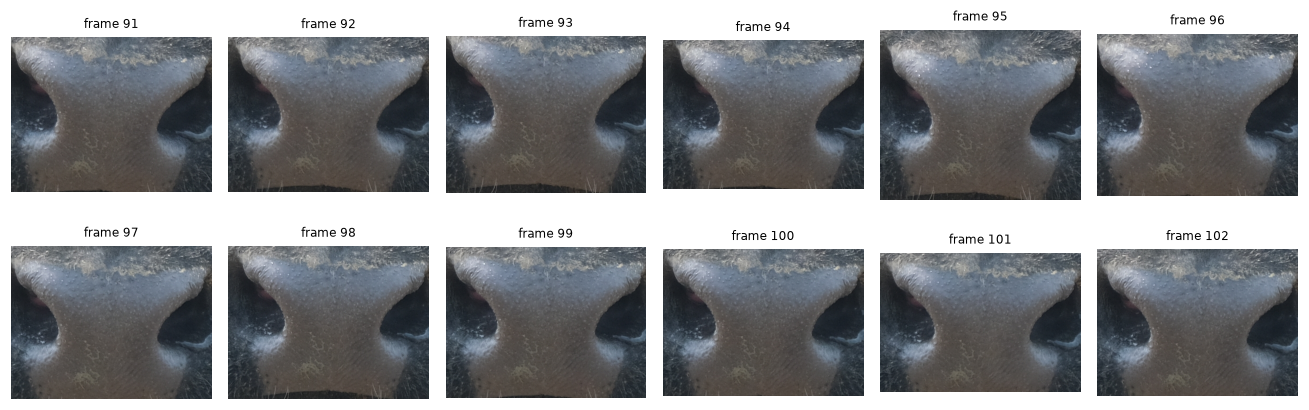

In [5]:
one = raw[raw["identity"] == "cattle_4381"].sort_values("frame").head(12)
show_grid(one["path"], [f"frame {f}" for f in one["frame"]])

The second gallery shows consecutive frames of one animal. Many look almost the same, which matters for the
evaluation (Section 3.2).

## 3. Data engineering

### 3.1 Duplicate identities

File names contain the camera frame number (`DSCF3856`). Two folders that contain crops of the *same* frame are
either the same animal filed twice, or two animals that stood in the same photo. SIFT keypoint matching on the
same-frame crops tells these apart: two crops of the same pixels give dozens to hundreds of geometric inliers,
while crops of two different muzzles give almost none.

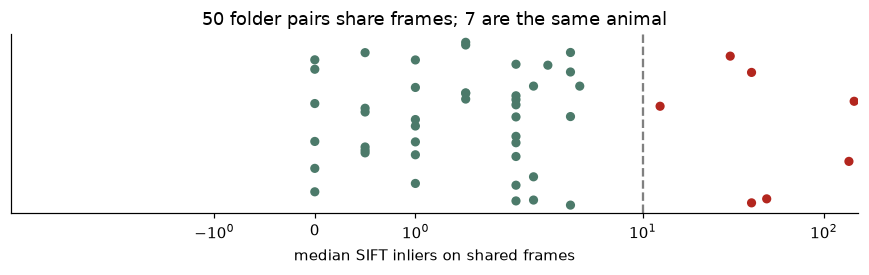

,identity_a,identity_b,shared_frames,median_inliers,same_animal
8,cattle_4451,cattle_4454,6,147.5,True
2,cattle_2000,cattle_2100,4,138.0,True
12,cattle_4613,cattle_5508,25,48.5,True
4,cattle_2000,cattle_8095,8,40.0,True
1,cattle_1900,cattle_6283,5,40.0,True
27,cattle_5407,cattle_6011,32,30.5,True
30,cattle_5408,cattle_6012,18,12.5,True
3,cattle_2000,cattle_8094,8,4.5,False
38,cattle_6276,cattle_6278,13,4.0,False
14,cattle_4678,cattle_4680,19,4.0,False


In [6]:
screen = prepared.shared_frame_screen.sort_values("median_inliers", ascending=False)
fig, ax = plt.subplots(figsize=(8, 2.6))
colors = np.where(screen["same_animal"], "#b3261e", "#4c7a6a")
ax.scatter(
    screen["median_inliers"],
    np.zeros(len(screen)) + np.random.default_rng(0).uniform(-1, 1, len(screen)),
    c=colors,
    s=25,
)
ax.axvline(dataset.SAME_ANIMAL_MIN_INLIERS, ls="--", c="grey")
ax.set(
    xscale="symlog",
    yticks=[],
    xlabel="median SIFT inliers on shared frames",
    title=f"{len(screen)} folder pairs share frames; {screen['same_animal'].sum()} are the same animal",
)
plt.tight_layout()
plt.show()
screen.head(10)

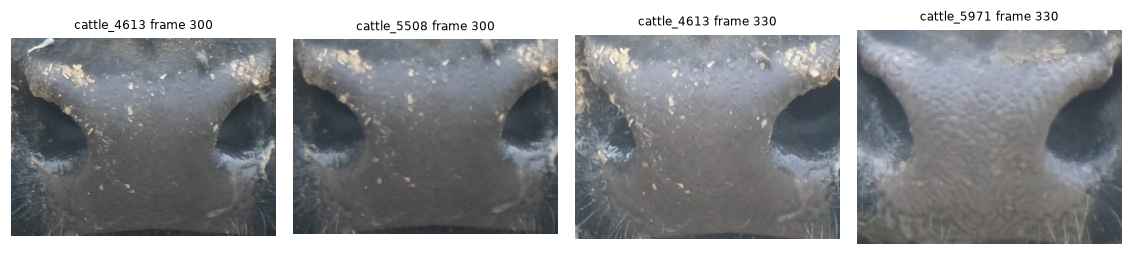

dropped: ['cattle_2100', 'cattle_4451', 'cattle_5408', 'cattle_5508', 'cattle_6011', 'cattle_6283', 'cattle_8095']


In [7]:
lookup = raw.dropna(subset=["frame"]).set_index(["identity", "frame"])["path"]
same = ("cattle_4613", "cattle_5508", 300)
other = ("cattle_4613", "cattle_5971", 330)
show_grid(
    [
        lookup[(same[0], same[2])],
        lookup[(same[1], same[2])],
        lookup[(other[0], other[2])],
        lookup[(other[1], other[2])],
    ],
    [
        f"{same[0]} frame {same[2]}",
        f"{same[1]} frame {same[2]}",
        f"{other[0]} frame {other[2]}",
        f"{other[1]} frame {other[2]}",
    ],
    cols=4,
    size=2.6,
)
print("dropped:", prepared.dropped_identities)

Left pair: one animal filed under two folder names. Right pair: two animals in one photo. Where several folders
show one animal, the folder with the most images is kept and the others are dropped, which removes 7 folders and
leaves 261 animals.

BC et al. (2026) also flagged duplicates by camera-frame provenance, confirmed them by visual review and removed 19
folders. Their list was not available, so the overlap with these 7 is unknown. The difference probably lies in the
decision rule: this screen needs identical frame numbers and a median of at least 10 SIFT inliers, and it does not
look at folders whose frames are adjacent but not shared. Some duplicates are therefore probably still present. If
such a pair falls in train and test, the test results are optimistic; if both fall in the test set, impostor scores
are pessimistic. Section 8 looks at the highest impostor scores for signs of this.

### 3.2 Near-duplicate images within an animal

Consecutive frames of a still animal can be near copies. If a query is a near copy of an enrolment image, the
genuine score says little about recognising the animal. A 64-bit difference hash (dHash) compares images cheaply.

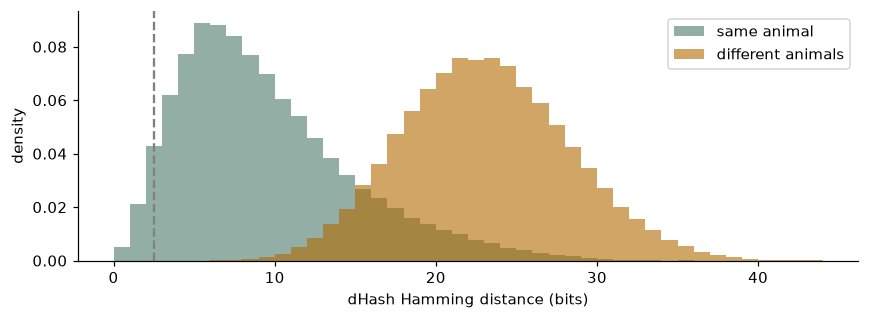

same-animal pairs within 2 bits: 6.9%; different-animal pairs within 2 bits: 0.000% of 59695
removed 1429 near-duplicates, kept 3395 images


In [8]:
rng = np.random.default_rng(0)
within = [
    dataset.hamming(a, b)
    for _, g in prepared.distinct.groupby("identity")
    for i, a in enumerate(g["dhash"])
    for b in list(g["dhash"])[i + 1 :]
]
h, ids = prepared.distinct["dhash"].to_numpy(), prepared.distinct["identity"].to_numpy()
pairs = rng.integers(len(h), size=(60000, 2))
across = [dataset.hamming(h[a], h[b]) for a, b in pairs if ids[a] != ids[b]]

fig, ax = plt.subplots(figsize=(8, 3))
bins = np.arange(0, 45)
ax.hist(within, bins=bins, density=True, alpha=0.6, label="same animal", color="#4c7a6a")
ax.hist(across, bins=bins, density=True, alpha=0.6, label="different animals", color="#b26a00")
ax.axvline(cfg["near_duplicate_max_bits"] + 0.5, ls="--", c="grey")
ax.set(xlabel="dHash Hamming distance (bits)", ylabel="density")
ax.legend()
plt.tight_layout()
plt.show()
t = cfg["near_duplicate_max_bits"]
print(
    f"same-animal pairs within {t} bits: {np.mean(np.array(within) <= t):.1%}; "
    f"different-animal pairs within {t} bits: {np.mean(np.array(across) <= t):.3%} of {len(across)}"
)
print(
    f"removed {len(prepared.distinct) - len(prepared.images)} near-duplicates, kept {len(prepared.images)} images"
)

Images within 2 bits of an image already kept for the same animal are removed, keeping the earliest frame. This is
a conservative cut: it removes only near copies, not every similar frame, so genuine pairs from what appears to be
one session remain easier than pairs taken on different days would be. Section 7 shows how the results change with
the cut.

### 3.3 Identity-disjoint split

Animals, not images, are assigned to train (60%), dev (20%) and test (20%) with a fixed seed. Train animals are
used only to fit the models. Dev animals are used only to set thresholds, choose the LBP encoder settings and monitor training (the final epoch
is always kept).
Test animals are used only for reporting, at the end. `splits.check_disjoint` fails if any animal or any identical file is in
more than one split.

In [9]:
data = e0.load()
images = data.images
splits.check_disjoint(images)
summary = (
    images.groupby("split")
    .agg(animals=("identity", "nunique"), images=("file", "size"))
    .loc[["train", "dev", "test"]]
)
for s in ["dev", "test"]:
    roles, _ = e0.split_with_roles(data, s)
    n_q, n_t = (roles["role"] == "query").sum(), roles["identity"].nunique()
    summary.loc[s, "enrolled animals"] = n_t
    summary.loc[s, "genuine comparisons"] = n_q
    summary.loc[s, "impostor comparisons"] = n_q * (n_t - 1)
summary.fillna("").astype(str)

,animals,images,enrolled animals,genuine comparisons,impostor comparisons
split,,,,,
train,157,2047,,,
dev,52,738,52.0,582.0,29682.0
test,52,610,51.0,454.0,22700.0


### 3.4 Enrolment and query protocol

For each dev and test animal, the first `k = 3` images in capture order form the template (the mean of their
L2-normalised embeddings) and every later image is a query. Each query is compared with its own template
(genuine) and with every other template in the same split (impostor). Capture order means a query is always taken
after enrolment, as in the study protocol. Animals with fewer than 4 images after cleaning cannot provide a query
and are left out of scoring.

### 3.5 Preprocessing

- **CNN models.** Each image is resized once to 256 x 256 (cached), then to 224 x 224 and normalised with ImageNet
  statistics. Training adds random resized crops (70 to 100% of the area), rotation up to 10 degrees and colour
  jitter. There is no horizontal flip, because a mirrored muzzle is a different ridge pattern.
- **LBP encoder.** Grayscale, centre square, area resize to `size` x `size`, uniform LBP codes, histograms on a
  `grid` x `grid` layout, square root and L2 normalisation. The same code runs in Dart in the app, where it is kept
  as a fallback; a parity test checks that both give the same vector.
- **Quality measures.** Grayscale centre square resized to 256 x 256; brightness is the mean, sharpness is the
  variance of the Laplacian.

## 4. Image quality

The app rejects images that are too small, too dark, too bright or too blurry (FR2). The limits below come from
the public images whose short side is at least 256 px, so they can be measured at full resolution. They are
starting values and will be revised with pilot images from the facility.

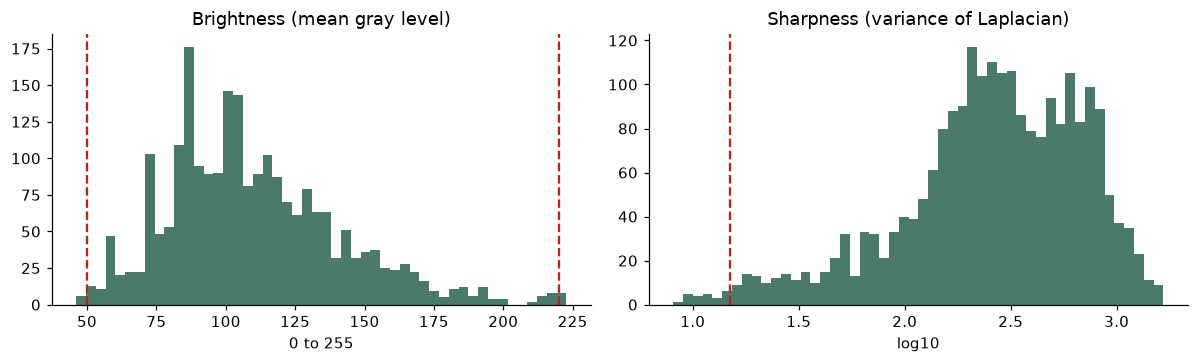

,value
images measured,2278
below min brightness,0.3%
above max brightness,0.2%
below min sharpness,1.0%
public images below min side (all sizes),53.7%


In [10]:
big = raw[np.minimum(raw["width"], raw["height"]) >= 256].copy()
measured = [quality.measure(load_rgb(paths.RAW / p)) for p in big["path"]]
big["brightness"] = [m.brightness for m in measured]
big["sharpness"] = [m.sharpness for m in measured]
q = cfg["app"]["quality"]

fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
ax[0].hist(big["brightness"], bins=50, color="#4c7a6a")
for v in (q["min_brightness"], q["max_brightness"]):
    ax[0].axvline(v, ls="--", c="#b3261e")
ax[0].set(title="Brightness (mean gray level)", xlabel="0 to 255")
ax[1].hist(np.log10(big["sharpness"]), bins=50, color="#4c7a6a")
ax[1].axvline(np.log10(q["min_sharpness"]), ls="--", c="#b3261e")
ax[1].set(title="Sharpness (variance of Laplacian)", xlabel="log10")
plt.tight_layout()
plt.show()
pd.Series(
    {
        "images measured": len(big),
        "below min brightness": f"{np.mean(big['brightness'] < q['min_brightness']):.1%}",
        "above max brightness": f"{np.mean(big['brightness'] > q['max_brightness']):.1%}",
        "below min sharpness": f"{np.mean(big['sharpness'] < q['min_sharpness']):.1%}",
        "public images below min side (all sizes)": f"{np.mean(short_side < q['min_side']):.1%}",
    }
).to_frame("value")

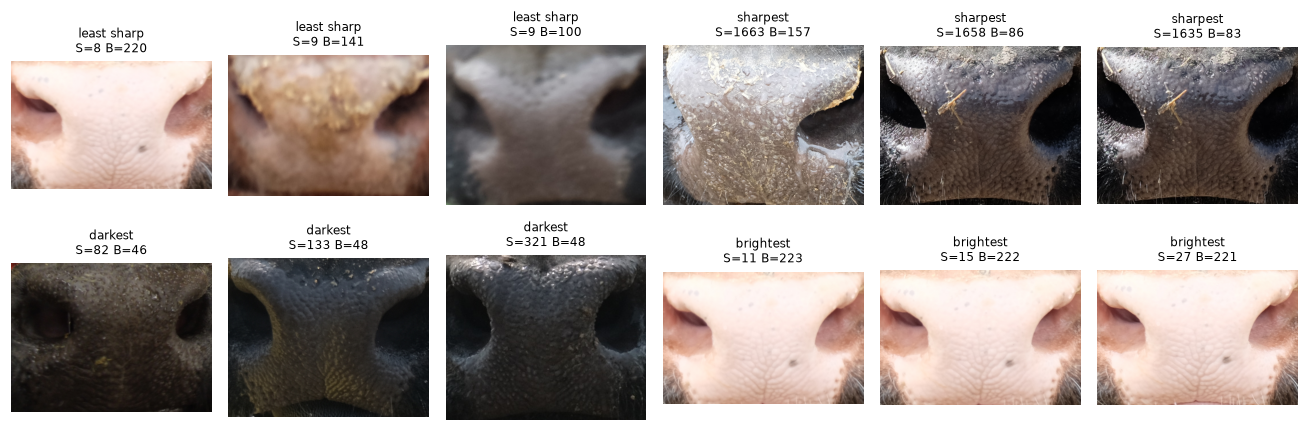

In [11]:
examples = pd.concat(
    [
        big.nsmallest(3, "sharpness").assign(kind="least sharp"),
        big.nlargest(3, "sharpness").assign(kind="sharpest"),
        big.nsmallest(3, "brightness").assign(kind="darkest"),
        big.nlargest(3, "brightness").assign(kind="brightest"),
    ]
)
show_grid(
    examples["path"],
    [
        f"{k}\nS={s:.0f} B={b:.0f}"
        for k, s, b in zip(
            examples["kind"], examples["sharpness"], examples["brightness"], strict=True
        )
    ],
)

The least sharp images are visibly out of focus, and the darkest and brightest are at the edges of normal
exposure. With these limits about 1% of the measured public images would be asked for a retake, which is the
intent: reject clear failures, not ordinary variation.

Two points to keep in mind. First, the brightest images are pale, unpigmented muzzles, and some of them also have
low sharpness scores even though they look in focus. The Laplacian measure responds to contrast as well as focus,
so the blur check may be too strict for pale muzzles. This needs checking on pilot images before the limit is
trusted. Second, more than half of the public crops are smaller than the 256 px the app requires. The app limit is
meant for phone photos, where the muzzle fills the guide square, so it is not applied to the public images in E0.

## 5. Baselines

All baselines use the same split, enrolment protocol and dev-set thresholds.

- **SIFT keypoint matching** (training-free). Score = largest number of RANSAC-consistent ratio-test matches between
  the query and any of the animal's enrolment images. Exhaustive RANSAC over every pair is slow, so each query is
  compared with its own animal and 10 randomly chosen other animals. Rank-1 and open-set rejection are not
  reported for SIFT because they need every template.
- **LBP histogram** (training-free). Kept in the mobile prototype as a fallback encoder. Its settings are chosen on
  dev animals only.
- **Frozen ImageNet MobileNetV3-Large** (training-free transfer). Global-average-pooled 960-d features from the
  pretrained backbone, with no cattle training. This is the image, crop, pretrained encoder, embedding, cosine
  similarity chain without any fine-tuning.
- **Softmax-trained MobileNetV3-Large.** The proposed backbone trained with a plain classification loss (Section 6).
  It isolates the effect of the angular margin.

The proposal names frozen DINOv2 features as the generic-feature baseline. It is not run here: frozen ImageNet
MobileNetV3 plays that role for E0, and DINOv2 is planned for the pilot check on the first linked live and
post-mortem pairs.

In [12]:
scores = {}
sift_dev = e0.sift_scores_for(data, "dev")
sift_test = e0.sift_scores_for(data, "test")
scores["SIFT"] = (sift_dev, sift_test)

lbp_rows, lbp_emb = [], {}
for size, grid in cfg["lbp_candidates"]:
    c = lbp.LbpConfig(size, grid)
    lbp_emb[(size, grid)] = e0.lbp_embeddings(data, c)
    s = e0.scores_for(data, lbp_emb[(size, grid)], "dev")
    g, i = s.loc[s["genuine"], "score"].to_numpy(), s.loc[~s["genuine"], "score"].to_numpy()
    lbp_rows.append(
        {
            "size": size,
            "grid": grid,
            "dim": c.dim,
            "dev ROC-AUC": metrics.roc_auc(g, i),
            "dev EER": metrics.eer(g, i)[0],
            "dev TAR@FAR1%": metrics.tar_at_far(g, i, 0.01),
        }
    )
lbp_sweep = pd.DataFrame(lbp_rows)
best = lbp_sweep.sort_values(["dev EER", "dim"]).iloc[0]
LBP = lbp.LbpConfig(int(best["size"]), int(best["grid"]))
print(f"selected on dev: size={LBP.size}, grid={LBP.grid}")
lbp_sweep.round(4)

selected on dev: size=64, grid=4


,size,grid,dim,dev ROC-AUC,dev EER,dev TAR@FAR1%
0,64,4,944,0.9433,0.1029,0.8282
1,96,4,944,0.9355,0.1319,0.7869
2,128,4,944,0.9301,0.1452,0.7680
3,128,8,3776,0.9425,0.1375,0.8007


In [13]:
lbp_all = lbp_emb[(LBP.size, LBP.grid)]
scores["LBP (on-device demo)"] = (
    e0.scores_for(data, lbp_all, "dev"),
    e0.scores_for(data, lbp_all, "test"),
)
imagenet_all = e0.imagenet_embeddings(data, device)
scores["MobileNetV3 ImageNet (frozen)"] = (
    e0.scores_for(data, imagenet_all, "dev"),
    e0.scores_for(data, imagenet_all, "test"),
)

## 6. Proposed model architecture

```
Input image (muzzle crop; full-frame detection is a later step)
    -> resize 224 x 224, ImageNet normalisation
    -> MobileNetV3-Large feature extractor (ImageNet weights)
    -> global average pooling (960)
    -> dropout 0.2, linear 960 -> 512, batch norm
    -> L2 normalisation  ->  embedding
    -> cosine similarity with the claimed animal's template (mean of k enrolment embeddings)
    -> thresholds tau(FAR 1%) and tau(FAR 0.1%) set on dev animals
    -> Match / Review / No match
```

During training only, an ArcFace head (Deng et al., 2019) adds an angular margin `m = 0.3` between each embedding
and its class centre, with scale `s = 30`, over the 157 training animals. The head is discarded after training,
so the network can embed animals it has never seen. MobileNetV3-Large is used because it is small enough for a
low-cost phone and because a pretrained backbone needs far fewer labelled animals than training from scratch. It
is not chosen as the most accurate backbone available.

The margin and scale are common defaults from metric-learning code, fixed before this run and not tuned. Deng et al.
used `s = 64`, `m = 0.5` on large face datasets; the AdaCos analysis (Zhang et al., 2019) suggests a smaller fixed
scale, about `sqrt(2) * ln(C - 1)`, roughly 7 for 157 classes. Since ArcFace and softmax are not separated in E0
(Section 7), a dev-only sweep of `s` and `m` is left for the study data.

In the full pipeline a YOLO-family detector will crop the muzzle (and the face for the comparator) from the
smartphone photo. The public images are already crops and have no bounding boxes, so the detector is not trained
here. It will be trained on manually labelled development images from the field study.

In [14]:
embedder = MuzzleEmbedder(cfg["train"]["embedding_dim"])
head = ArcFaceHead(
    cfg["train"]["embedding_dim"], 157, cfg["train"]["arc_scale"], cfg["train"]["arc_margin"]
)
n_backbone = sum(p.numel() for p in embedder.parameters())
n_head = sum(p.numel() for p in head.parameters())
pd.Series(
    {
        "embedder parameters": f"{n_backbone:,}",
        "embedder size, float32": f"{n_backbone * 4 / 1e6:.1f} MB",
        "ArcFace head parameters (training only)": f"{n_head:,}",
        "training config": json.dumps(cfg["train"]),
    }
).to_frame("value")

,value
embedder parameters,"3,465,008"
"embedder size, float32",13.9 MB
ArcFace head parameters (training only),"80,384"
training config,"{""loss"": ""arcface"", ""epochs"": 15, ""batch_size""..."


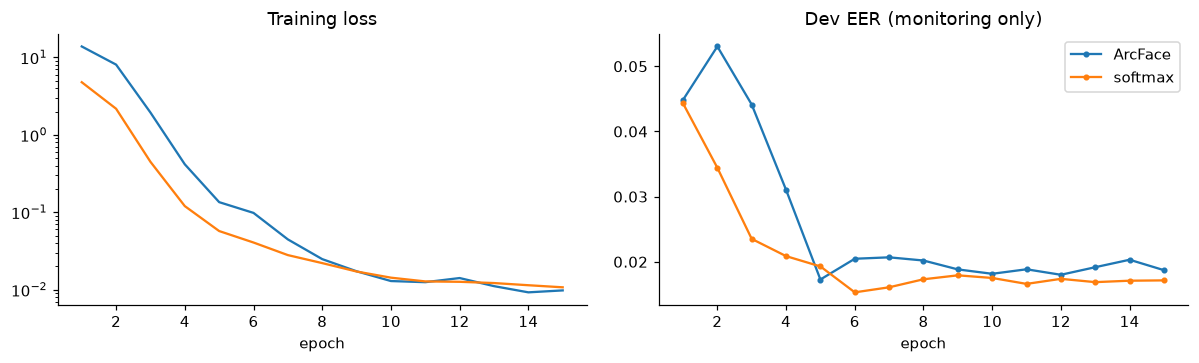

,epoch,train_loss,train_acc,dev_roc_auc,dev_eer
0,1,13.8577,0.0000,0.9911,0.0448
1,2,8.0751,0.0962,0.9905,0.0530
2,3,1.9410,0.6751,0.9944,0.0441
3,4,0.4163,0.9251,0.9968,0.0310
4,5,0.1350,0.9752,0.9990,0.0173
5,6,0.0981,0.9812,0.9984,0.0205
6,7,0.0446,0.9931,0.9988,0.0207
7,8,0.0248,0.9975,0.9989,0.0202
8,9,0.0173,0.9990,0.9990,0.0188
9,10,0.0129,1.0000,0.9990,0.0182


In [15]:
arc_model, arc_hist = e0.train(data, "arcface", device)
soft_model, soft_hist = e0.train(data, "softmax", device)

fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
for name, h in [("ArcFace", arc_hist), ("softmax", soft_hist)]:
    ax[0].plot(h["epoch"], h["train_loss"], label=name)
    ax[1].plot(h["epoch"], h["dev_eer"], marker="o", ms=3, label=name)
ax[0].set(title="Training loss", xlabel="epoch", yscale="log")
ax[1].set(title="Dev EER (monitoring only)", xlabel="epoch")
ax[1].legend()
plt.tight_layout()
plt.show()
arc_hist.round(4)

In [16]:
arc_all = e0.cnn_embeddings(data, arc_model, device)
soft_all = e0.cnn_embeddings(data, soft_model, device)
scores["MobileNetV3 softmax"] = (
    e0.scores_for(data, soft_all, "dev"),
    e0.scores_for(data, soft_all, "test"),
)
scores["MobileNetV3 ArcFace (proposed)"] = (
    e0.scores_for(data, arc_all, "dev"),
    e0.scores_for(data, arc_all, "test"),
)

## 7. Initial performance (test animals)

Protocol: E0, live-to-live, identity-disjoint, `k = 3` enrolment images in capture order, thresholds fixed on dev
animals and applied unchanged to test animals. *Oracle* TAR uses a threshold chosen on the test impostors
themselves and is shown only for comparison with other papers; *calibrated* TAR and *realised* FAR use the dev
thresholds and are the honest operating numbers. Confidence intervals are 95% bootstrap intervals over test
animals (2,000 resamples). Each resample draws animals with replacement and keeps the comparisons between drawn
animals, so both the query animal and the template animal of an impostor pair are resampled (the subsets bootstrap of
Bolle, Ratha and Pankanti, 2004).

TAR and FAR here are comparison-level rates: each query image is compared once with one template, and images
rejected by a quality check are not counted. In ISO/IEC 19795-1 terms they are 1 - FNMR and FMR.

In [17]:
results = [
    e0.report(name, dev, test, cfg, exhaustive=(name != "SIFT"))
    for name, (dev, test) in scores.items()
]
table = pd.DataFrame(results).set_index("model")


def ci(row, key):
    lo, hi = row[f"{key}_ci"]
    return f"{row[key]:.3f} [{lo:.3f}, {hi:.3f}]"


view = pd.DataFrame(
    {
        "genuine / impostor": [f"{r.n_genuine} / {r.n_impostor}" for r in table.itertuples()],
        "ROC-AUC": table["roc_auc"].round(4),
        "EER [95% CI]": [ci(r, "eer") for _, r in table.iterrows()],
        "TAR@FAR1% calibrated [95% CI]": [
            ci(r, "calibrated_tar_at_far1") for _, r in table.iterrows()
        ],
        "realised FAR (target 1%) [95% CI]": [
            f"{r['realised_far_at_far1']:.2%} [{r['realised_far_at_far1_ci'][0]:.2%}, "
            f"{r['realised_far_at_far1_ci'][1]:.2%}]"
            for _, r in table.iterrows()
        ],
        "TAR@FAR0.1% calibrated": table["calibrated_tar_at_far01"].round(3),
        "realised FAR (target 0.1%)": (table["realised_far_at_far01"] * 100).round(2).astype(str)
        + "%",
        "TAR@FAR1% oracle": table["oracle_tar_at_far1"].round(3),
        "Rank-1": table.get("rank1").round(3),
        "open-set rejection @tau1": table.get("open_set_rejection_at_far1").round(3),
    },
    index=table.index,
)
view

,genuine / impostor,ROC-AUC,EER [95% CI],TAR@FAR1% calibrated [95% CI],realised FAR (target 1%) [95% CI],TAR@FAR0.1% calibrated,realised FAR (target 0.1%),TAR@FAR1% oracle,Rank-1,open-set rejection @tau1
model,,,,,,,,,,
SIFT,454 / 4540,0.9683,"0.077 [0.033, 0.105]","0.751 [0.609, 0.870]","0.18% [0.00%, 0.59%]",0.678,0.02%,0.804,NaN,NaN
LBP (on-device demo),454 / 22700,0.9362,"0.112 [0.062, 0.170]","0.784 [0.692, 0.867]","0.50% [0.13%, 1.12%]",0.709,0.02%,0.811,0.925,0.857
MobileNetV3 ImageNet (frozen),454 / 22700,0.9682,"0.066 [0.036, 0.104]","0.885 [0.819, 0.941]","0.50% [0.17%, 0.99%]",0.800,0.0%,0.890,0.925,0.802
MobileNetV3 softmax,454 / 22700,0.9926,"0.025 [0.009, 0.057]","0.956 [0.913, 0.989]","0.89% [0.35%, 1.67%]",0.885,0.12%,0.958,0.960,0.621
MobileNetV3 ArcFace (proposed),454 / 22700,0.9940,"0.022 [0.005, 0.056]","0.965 [0.924, 0.995]","0.87% [0.32%, 1.72%]",0.932,0.17%,0.969,0.971,0.648


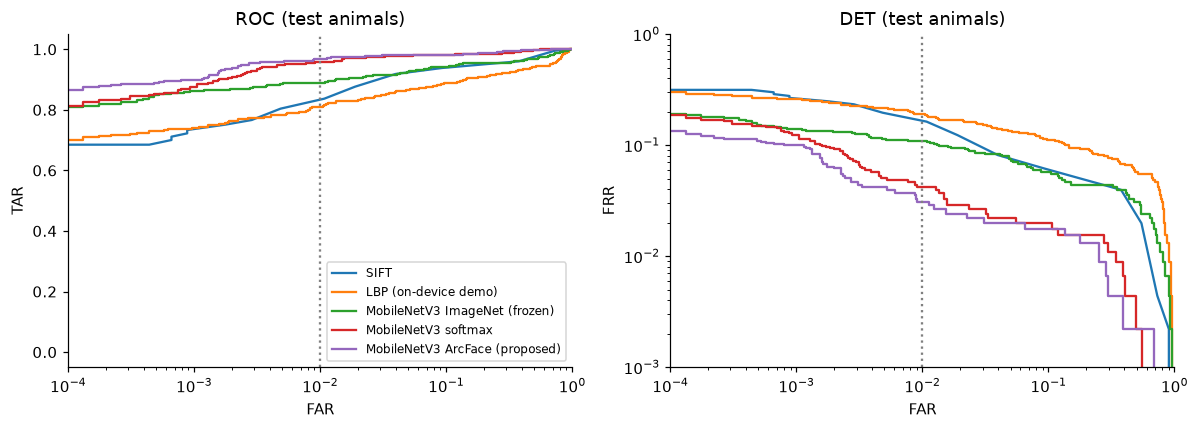

In [18]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
for name, (_, test) in scores.items():
    g, i = (
        test.loc[test["genuine"], "score"].to_numpy(),
        test.loc[~test["genuine"], "score"].to_numpy(),
    )
    far, tar, _ = roc_curve(np.r_[np.ones(len(g)), np.zeros(len(i))], np.r_[g, i])
    ax[0].plot(far, tar, label=name)
    ax[1].plot(far, 1 - tar, label=name)
ax[0].set(xscale="log", xlim=(1e-4, 1), xlabel="FAR", ylabel="TAR", title="ROC (test animals)")
ax[1].set(
    xscale="log",
    yscale="log",
    xlim=(1e-4, 1),
    ylim=(1e-3, 1),
    xlabel="FAR",
    ylabel="FRR",
    title="DET (test animals)",
)
for a in ax:
    a.axvline(0.01, ls=":", c="grey")
ax[0].legend(fontsize=8, loc="lower right")
plt.tight_layout()
plt.savefig(FIGURES / "e0_roc_det.png", dpi=150)
plt.show()

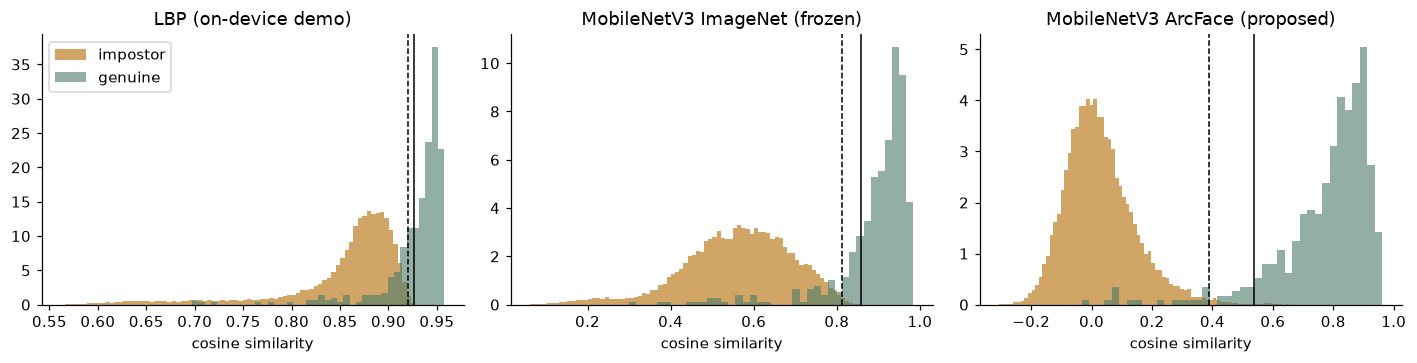

In [19]:
show = ["LBP (on-device demo)", "MobileNetV3 ImageNet (frozen)", "MobileNetV3 ArcFace (proposed)"]
fig, axes = plt.subplots(1, 3, figsize=(13, 3.4))
for ax, name in zip(axes, show, strict=True):
    _, test = scores[name]
    r = table.loc[name]
    ax.hist(
        test.loc[~test["genuine"], "score"],
        bins=80,
        density=True,
        alpha=0.6,
        label="impostor",
        color="#b26a00",
    )
    ax.hist(
        test.loc[test["genuine"], "score"],
        bins=40,
        density=True,
        alpha=0.6,
        label="genuine",
        color="#4c7a6a",
    )
    ax.axvline(r["tau_far1"], ls="--", c="k", lw=1)
    ax.axvline(r["tau_far01"], ls="-", c="k", lw=1)
    ax.set(title=name, xlabel="cosine similarity")
axes[0].legend()
plt.tight_layout()
plt.savefig(FIGURES / "e0_score_distributions.png", dpi=150)
plt.show()

Dashed line: dev threshold at FAR 1% (below it is *No match*). Solid line: dev threshold at FAR 0.1% (at or above
it is *Match*). Between them is *Review*.

In [20]:
# Every row uses the same queries: images from the 6th onwards. Only the number of enrolment images changes.
k_rows = []
for name, emb in [("LBP (on-device demo)", lbp_all), ("MobileNetV3 ArcFace (proposed)", arc_all)]:
    for k in (1, 3, 5):
        dev_k = e0.scores_for(data, emb, "dev", k, query_start=5)
        test_k = e0.scores_for(data, emb, "test", k, query_start=5)
        th = e0.calibrate(dev_k)
        s = metrics.summarise(test_k, th["tau_far1"], th["tau_far01"])
        k_rows.append(
            {
                "model": name,
                "k": k,
                "test animals": test_k["query_identity"].nunique(),
                "genuine": s["n_genuine"],
                "EER": s["eer"],
                "TAR@FAR1% calibrated": s["calibrated_tar_at_far1"],
                "realised FAR": s["realised_far_at_far1"],
            }
        )
pd.DataFrame(k_rows).round(4)

,model,k,test animals,genuine,EER,TAR@FAR1% calibrated,realised FAR
0,LBP (on-device demo),1,46,352,0.1448,0.6705,0.0052
1,LBP (on-device demo),3,46,352,0.1299,0.7415,0.0044
2,LBP (on-device demo),5,46,352,0.1190,0.7784,0.0054
3,MobileNetV3 ArcFace (proposed),1,46,352,0.0306,0.9517,0.0097
4,MobileNetV3 ArcFace (proposed),3,46,352,0.0304,0.9545,0.0091
5,MobileNetV3 ArcFace (proposed),5,46,352,0.0224,0.9574,0.0092


In [21]:
# The ArcFace model is fixed; only the dev and test images kept by the near-duplicate cut change.
assign = dict(zip(images["identity"], images["split"], strict=True))
dedup_rows = []
for bits in (0, 2, 4, 6):
    kept = dataset.remove_near_duplicates(prepared.distinct, bits)
    kept = kept.assign(split=kept["identity"].map(assign))
    kept = kept[kept["split"].isin(["dev", "test"])].reset_index(drop=True)
    subset = e0.from_images(cfg, kept, cache=False)
    emb = e0.cnn_embeddings(subset, arc_model, device)
    dev_b, test_b = e0.scores_for(subset, emb, "dev"), e0.scores_for(subset, emb, "test")
    th = e0.calibrate(dev_b)
    s = metrics.summarise(test_b, th["tau_far1"], th["tau_far01"])
    dedup_rows.append(
        {
            "max bits": bits,
            "dev + test images": len(kept),
            "test genuine": s["n_genuine"],
            "test EER": s["eer"],
            "TAR@FAR1% calibrated": s["calibrated_tar_at_far1"],
            "realised FAR": s["realised_far_at_far1"],
        }
    )
pd.DataFrame(dedup_rows).round(4)

,max bits,dev + test images,test genuine,test EER,TAR@FAR1% calibrated,realised FAR
0,0,1824,701,0.0220,0.9743,0.0100
1,2,1348,454,0.0223,0.9648,0.0087
2,4,860,229,0.0335,0.9432,0.0078
3,6,582,115,0.0393,0.9391,0.0070


**What the numbers say**

- The fine-tuned MobileNetV3 models are clearly better than the training-free baselines. ArcFace has the lowest
  EER (2.2%) and the highest calibrated TAR at FAR 1% (96.5%), but its confidence intervals overlap with the
  softmax model. With 52 test animals, E0 does not show that the angular margin is better than plain softmax.
- Frozen ImageNet features already separate most pairs (ROC-AUC 0.968), so pretrained features carry useful
  texture information, and fine-tuning on 157 animals roughly divides the EER by three.
- The LBP encoder is the weakest model: EER 11.2% and TAR 78.4% at the dev FAR 1% threshold. This is why the app
  runs the ArcFace model and keeps LBP only as a fallback.
- Dev thresholds transferred reasonably: the realised test FAR stayed at or below the 1% target for every model
  (0.18% to 0.89%), although the upper ends of the intervals for the fine-tuned models reach about 1.7%. At the 0.1% target, the dev threshold is set by about 30 dev impostor scores, and the realised
  FAR overshot for both fine-tuned models (0.12% softmax, 0.17% ArcFace). Those numbers are exploratory only.
- Open-set rejection is much lower than the 1:1 numbers suggest (64.8% for ArcFace). When a query is compared with
  all 50 other templates, a 1% chance of a false accept per comparison adds up across the gallery. A 1:N search
  needs a stricter threshold than 1:1 verification. This matters for E6 in the study.
- More enrolment images help. With the same 352 queries from 46 test animals in every row, ArcFace EER falls from
  3.1% (k = 1) to 2.2% (k = 5), and LBP from 14.5% to 11.9%. The intervals are wide, so this is a trend, not a
  firm result.
- The results depend on how strictly near-duplicate frames are removed. With the model fixed, test EER is 2.2% when
  only exact copies are dropped (0 bits) or at the chosen 2-bit cut, 3.4% at 4 bits and 3.9% at 6 bits. Stricter
  cuts leave fewer and harder genuine pairs (454 at 2 bits, 115 at 6 bits). The 2-bit cut was chosen after seeing
  the E0-a results, so the reported numbers should be read as optimistic for photos taken further apart.

**Protocol caveat.** Enrolment and query images of an animal appear to come from one session: where EXIF times exist
(23 animals), each animal's images span at most 72 minutes on one day. These are live-to-live numbers for feedlot
cattle in one US study. They are the reference point the study will compare against, not evidence about
post-mortem use.

## 8. Error analysis

The examples below use the proposed ArcFace model on test animals. Each row shows the query first, then the three
enrolment images of the template it was compared with.

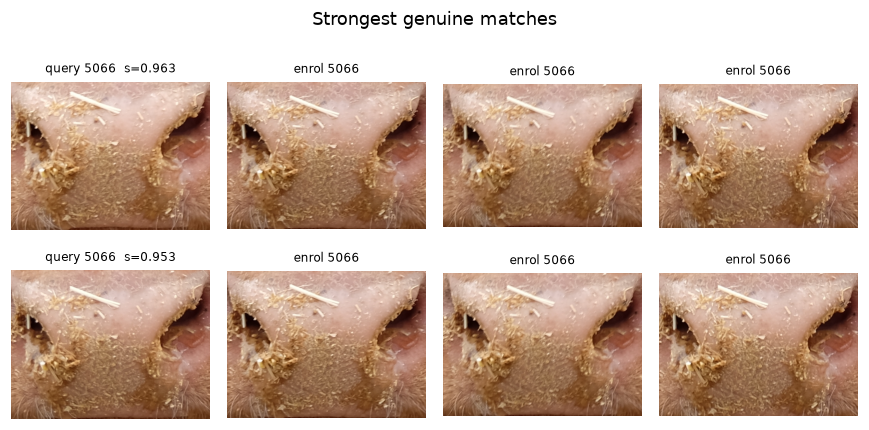

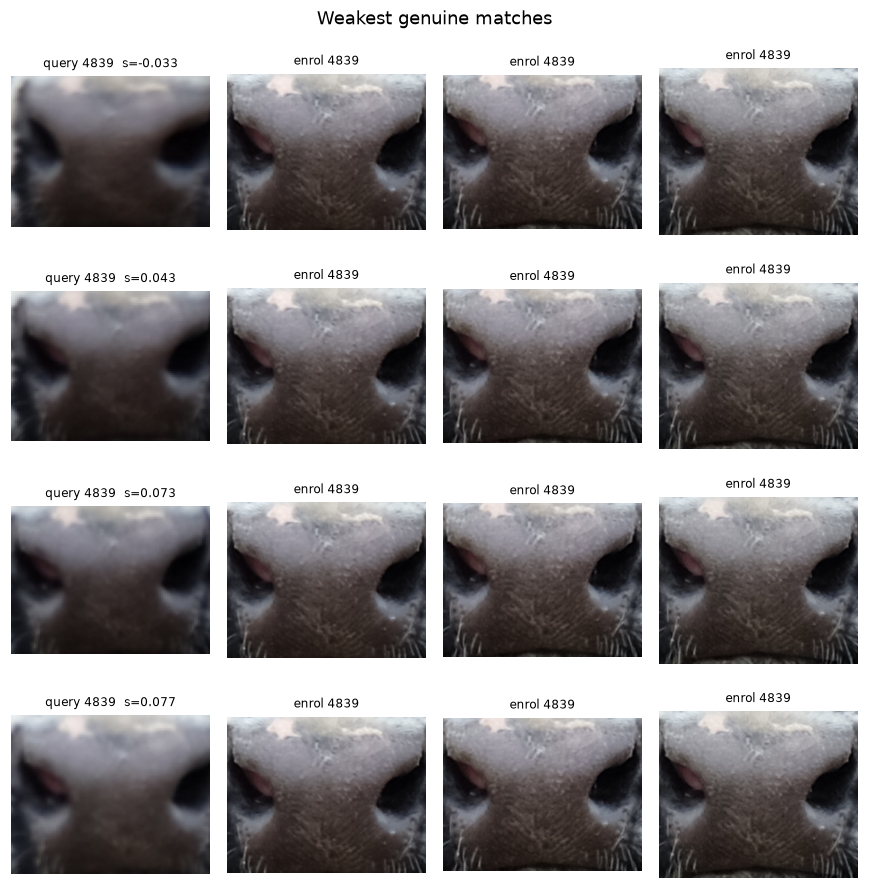

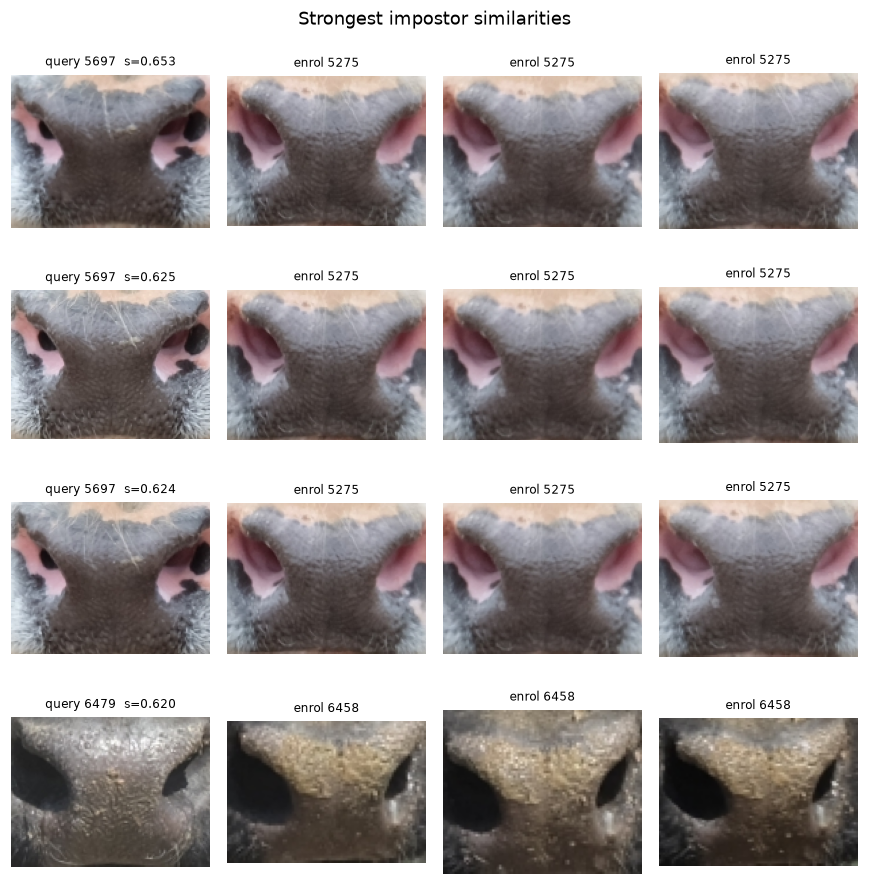

In [22]:
_, arc_test = scores["MobileNetV3 ArcFace (proposed)"]
roles_test, pos_test = e0.split_with_roles(data, "test")
roles_test = roles_test.reset_index(drop=True)
enrol_paths = roles_test[roles_test["role"] == "enrol"].groupby("identity")["path"].apply(list)


def show_pairs(rows, title):
    fig, axes = plt.subplots(len(rows), 4, figsize=(8, 2.1 * len(rows)))
    for ax_row, (_, r) in zip(np.atleast_2d(axes), rows.iterrows(), strict=True):
        q = roles_test.loc[r["query_pos"]]
        imgs = [q["path"], *enrol_paths[r["template_identity"]]]
        for j, (ax, p) in enumerate(zip(ax_row, imgs, strict=True)):
            ax.imshow(load_rgb(paths.RAW / p))
            ax.axis("off")
            ax.set_title(
                f"query {q['identity'][-4:]}  s={r['score']:.3f}"
                if j == 0
                else f"enrol {r['template_identity'][-4:]}",
                fontsize=8,
            )
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()


genuine = arc_test[arc_test["genuine"]]
impostor = arc_test[~arc_test["genuine"]]
show_pairs(genuine.nlargest(2, "score"), "Strongest genuine matches")
show_pairs(genuine.nsmallest(4, "score"), "Weakest genuine matches")
show_pairs(impostor.nlargest(4, "score"), "Strongest impostor similarities")

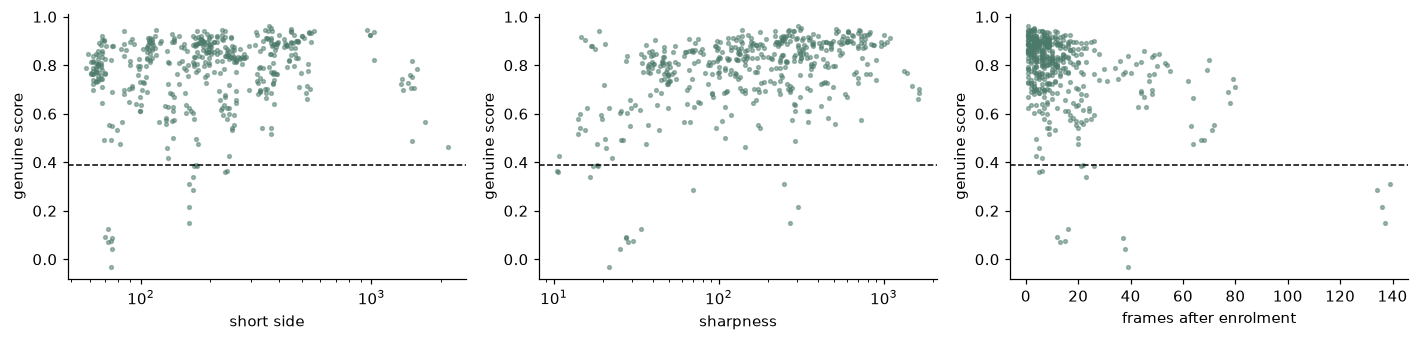

,Spearman rho,p-value
short_side,0.188,0.00
sharpness,0.406,0.00
brightness,0.037,0.43
frames_after_enrolment,-0.384,0.00


In [23]:
q_meta = roles_test.assign(query_pos=roles_test.index)
q_meta["short_side"] = np.minimum(q_meta["width"], q_meta["height"])
q_meta["sharpness"] = [quality.measure(load_rgb(paths.RAW / p)).sharpness for p in q_meta["path"]]
q_meta["brightness"] = [quality.measure(load_rgb(paths.RAW / p)).brightness for p in q_meta["path"]]
g = genuine.merge(
    q_meta[["query_pos", "short_side", "sharpness", "brightness", "frame"]], on="query_pos"
)
enrol_last = roles_test[roles_test["role"] == "enrol"].groupby("identity")["frame"].max()
g["frames_after_enrolment"] = g["frame"] - g["query_identity"].map(enrol_last)

fig, ax = plt.subplots(1, 3, figsize=(13, 3.2))
for a, col, log in zip(
    ax, ["short_side", "sharpness", "frames_after_enrolment"], [True, True, False], strict=True
):
    a.scatter(g[col], g["score"], s=6, alpha=0.5, color="#4c7a6a")
    a.axhline(table.loc["MobileNetV3 ArcFace (proposed)", "tau_far1"], ls="--", c="k", lw=1)
    a.set(xlabel=col.replace("_", " "), ylabel="genuine score", xscale="log" if log else "linear")
plt.tight_layout()
plt.show()
pd.DataFrame(
    {
        col: spearmanr(g[col], g["score"], nan_policy="omit")
        for col in ["short_side", "sharpness", "brightness", "frames_after_enrolment"]
    },
    index=["Spearman rho", "p-value"],
).T.round(3)

In [24]:
fails = g[g["score"] < table.loc["MobileNetV3 ArcFace (proposed)", "tau_far1"]]
print(
    f"genuine queries below tau(FAR 1%): {len(fails)} of {len(g)} from {fails['query_identity'].nunique()} animals"
)
fails.groupby("query_identity").size().sort_values(ascending=False).head(10).to_frame(
    "rejected genuine queries"
)

genuine queries below tau(FAR 1%): 16 of 454 from 4 animals


,rejected genuine queries
query_identity,
cattle_4839,7
cattle_4369,4
cattle_5809,3
cattle_5009,2


**What the model struggles with**

- **Blur.** The weakest genuine matches all come from one animal (`cattle_4839`) whose query images are badly out
  of focus while the enrolment images are sharp. Its scores are close to zero. Across all genuine pairs, the score
  correlates with query sharpness (Spearman rho 0.41). This supports rejecting blurred images at capture time.
- **Time within the session.** Genuine scores fall as the query is taken later after enrolment (rho -0.38), even
  within what appears to be one session. Changes in pose, moisture and lighting over a few minutes already cost similarity. The gap
  between live enrolment and post-mortem capture will be much larger.
- **Concentrated failures.** The 16 genuine queries rejected at the FAR 1% threshold come from only 4 animals. A
  few hard animals dominate the error rate, which is why confidence intervals are computed over animals.
- **Lookalike impostors.** The highest impostor scores (about 0.65, above the Match threshold) pair animals with a
  similar muzzle shape, nostril colour and framing. By eye they appear to be different animals, so the model seems
  to use global appearance such as colour and shape, not only the ridge pattern. Nostril colour and moisture may
  change after death, so this is a specific risk for the post-mortem experiment. One pair (`cattle_6479` and
  `cattle_6458`) cannot be judged from these crops and may be an undetected duplicate.

## 9. Limitations

- **Live animals only.** Every image here is of a live animal. E0 says nothing about whether the muzzle pattern
  still identifies an animal after slaughter. That is the central research question and needs the paired
  ante-mortem and post-mortem dataset, which has not been collected yet.
- **Probably one session per animal, one study, one main camera.** Genuine pairs appear to come from one photo
  session per animal (EXIF times, where present, span at most 72 minutes), on feedlot cattle from one US study,
  mostly with one mirrorless camera model. Near copies were removed, but enrolment and query images are still close
  in time, under the same light and handling. Section 7 shows that stricter near-duplicate removal raises the EER. The planned study adds slaughter, a second phone and Rwandan cattle,
  each of which can lower performance.
- **Pre-cropped images.** The public data are tight muzzle crops chosen by the dataset authors. The app will need a
  detector to find the muzzle in a full phone photo, and detection errors will add to verification errors.
- **Incomplete duplicate cleaning.** The provenance screen removed 7 duplicate folders; BC et al. (2026) report 19,
  and the overlap is unknown. Remaining duplicates could bias results in either direction (Section 3.1).
- **Small test set.** 52 test animals give a few thousand impostor comparisons. FAR 0.1% thresholds rest on a
  handful of dev impostor scores and are exploratory only. The confidence intervals show how wide the estimates are.
- **Not an operational result.** These numbers do not show that the system is suitable for insurance, traceability
  or any decision about a real animal.

## 10. Save results

The results file records every number above. The phone model is exported from the same ArcFace weights by
`ml/scripts/export_tflite.py`, which sets the app's thresholds again on dev animals with the phone's exact
preprocessing, and `ml/scripts/export_app_manifest.py` writes the manifest the app loads.

In [25]:
def jsonable(v):
    if isinstance(v, (np.floating, np.integer)):
        return v.item()
    if isinstance(v, tuple):
        return [jsonable(x) for x in v]
    return v


out = {
    "experiment": "E0",
    "description": cfg["description"],
    "data": {
        "raw_identities": int(raw["identity"].nunique()),
        "raw_images": len(raw),
        "dropped_duplicate_identities": prepared.dropped_identities,
        "near_duplicates_removed": len(prepared.distinct) - len(prepared.images),
        "split": {
            s: {
                "animals": int(images[images.split == s].identity.nunique()),
                "images": int((images.split == s).sum()),
            }
            for s in ["train", "dev", "test"]
        },
    },
    "config": cfg,
    "lbp_selected": LBP.to_dict(),
    "lbp_sweep_dev": lbp_sweep.to_dict(orient="records"),
    "results_test": [{k: jsonable(v) for k, v in r.items()} for r in results],
    "environment": {
        "python": platform.python_version(),
        "torch": torch.__version__,
        "device": str(device),
    },
}
path = paths.EXPERIMENTS / "e0_results.json"
path.write_text(json.dumps(out, indent=2))
print(f"wrote {path.relative_to(paths.REPO)}")

wrote ml/experiments/e0_results.json
